# Self-Refining Code Generation — Progress through M5

This notebook is the running presentation summary for supervisor meetings. It is updated after each milestone; full technical evidence remains in `experiments/results/` and `docs/validation/`.

- **M1:** end-to-end mock pipeline and sandboxed execution complete
- **M2:** real-model single-pass development baselines complete
- **M3:** iterative template-feedback refinement complete
- **M4:** compute-matched best-of-five fairness baseline complete
- **M5:** template, trace, and hybrid feedback comparison complete

> All results shown here are local 4-bit Qwen development measurements on frozen dev splits. Dissertation-reported results will come from full-precision GPU runs.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "experiments" / "results").is_dir():
    ROOT = ROOT.parent
RESULTS = ROOT / "experiments" / "results"
assert RESULTS.is_dir(), "Run this notebook from the repository or notebooks directory"

RUNS = {
    "single": {
        "HumanEval-Dev": RESULTS / "20260713T131758.814615Z_m2_qwen_ollama_zero_shot_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T200916.764652Z_m2_qwen_ollama_zero_shot_mbpp_dev",
    },
    "refined": {
        "HumanEval-Dev": RESULTS / "20260713T191841.745630Z_m3_qwen_ollama_template_refinement_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T201936.683659Z_m3_qwen_ollama_template_refinement_mbpp_dev",
    },
    "bo5": {
        "HumanEval-Dev": RESULTS / "20260713T193041.127180Z_m4_qwen_ollama_best_of_5_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T201055.926372Z_m4_qwen_ollama_best_of_5_mbpp_dev",
    },
    "template": {
        "HumanEval-Dev": RESULTS / "20260713T222148.461537Z_m5_qwen_ollama_template_refinement_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T222826.453953Z_m5_qwen_ollama_template_refinement_mbpp_dev",
    },
    "trace": {
        "HumanEval-Dev": RESULTS / "20260713T222522.003946Z_m5_qwen_ollama_trace_refinement_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T223141.925579Z_m5_qwen_ollama_trace_refinement_mbpp_dev",
    },
    "hybrid": {
        "HumanEval-Dev": RESULTS / "20260713T222718.512169Z_m5_qwen_ollama_hybrid_refinement_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T223538.251373Z_m5_qwen_ollama_hybrid_refinement_mbpp_dev",
    },
}
INVALID_MBPP = RESULTS / "20260713T194903.209391Z_m2_qwen_ollama_zero_shot_mbpp_dev"

for group in RUNS.values():
    for run in group.values():
        assert (run / "summary.csv").is_file(), f"Missing result artifact: {run}"

def summary_row(run):
    frame = pd.read_csv(run / "summary.csv")
    assert len(frame) == 1
    return frame.iloc[0]

def problem_record(run, task_id):
    filename = task_id.replace("/", "_") + ".json"
    return json.loads((run / "problems" / filename).read_text())

def label_bars(ax, digits=2):
    for container in ax.containers:
        ax.bar_label(container, fmt=f"%.{digits}f", padding=3, fontsize=9)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#4472C4", "#70AD47", "#ED7D31"]
pd.set_option("display.precision", 3)

## M2 — Single-pass baseline

,pass@1_single
Benchmark,
HumanEval-Dev,0.85
MBPP-Dev,0.76


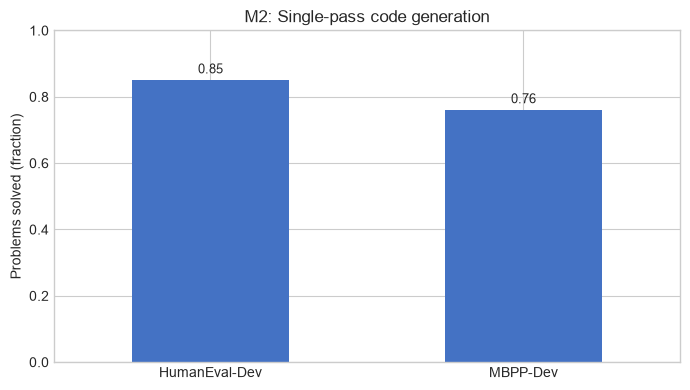

In [2]:
m2 = pd.DataFrame(
    [
        {"Benchmark": benchmark, "pass@1_single": summary_row(run)["value"]}
        for benchmark, run in RUNS["single"].items()
    ]
).set_index("Benchmark")
display(m2.style.format("{:.2f}").set_caption("M2 measured dev-set baseline"))
ax = m2.plot.bar(color=COLORS[0], figsize=(7, 4), legend=False, ylim=(0, 1))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M2: Single-pass code generation")
ax.tick_params(axis="x", rotation=0)
label_bars(ax)
plt.tight_layout()
plt.show()

## M3 — Iterative refinement

Configuration,Single pass,Template refinement
Benchmark,,
HumanEval-Dev,0.85,0.95
MBPP-Dev,0.76,0.78


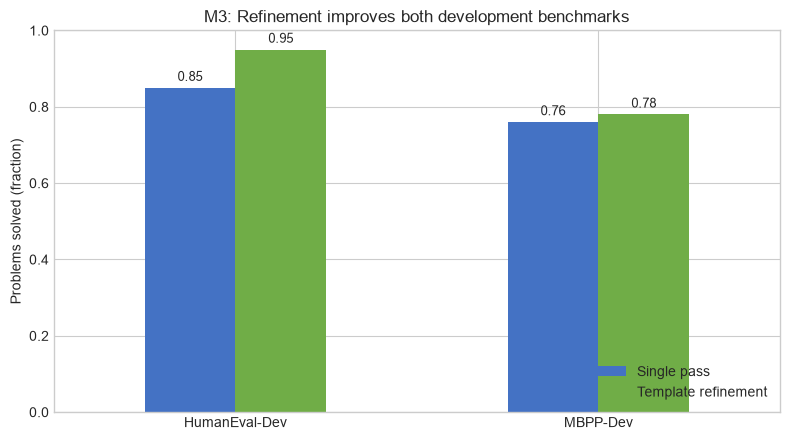

<div style='padding:12px;border-left:5px solid #ED7D31;background:#fff4e8'><b>HumanEval/46:</b> feedback correctly exposed the output mismatch, but the model repeated its code and stopped by <b>oscillation</b> after <b>2</b> iterations. Better evidence does not guarantee correction.</div>

In [3]:
m3_rows = []
for benchmark in RUNS["single"]:
    m3_rows.extend([
        {"Benchmark": benchmark, "Configuration": "Single pass", "Score": summary_row(RUNS["single"][benchmark])["value"]},
        {"Benchmark": benchmark, "Configuration": "Template refinement", "Score": summary_row(RUNS["refined"][benchmark])["value"]},
    ])
m3 = pd.DataFrame(m3_rows).pivot(index="Benchmark", columns="Configuration", values="Score")
m3 = m3[["Single pass", "Template refinement"]]
display(m3.style.format("{:.2f}").set_caption("M3: single pass versus iterative refinement"))
ax = m3.plot.bar(color=COLORS[:2], figsize=(8, 4.5), ylim=(0, 1))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M3: Refinement improves both development benchmarks")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", loc="lower right")
label_bars(ax)
plt.tight_layout()
plt.show()

he46 = problem_record(RUNS["refined"]["HumanEval-Dev"], "HumanEval/46")
display(Markdown(
    f"<div style='padding:12px;border-left:5px solid #ED7D31;background:#fff4e8'>"
    f"<b>HumanEval/46:</b> feedback correctly exposed the output mismatch, but the model repeated its code and stopped by "
    f"<b>{he46['convergence_reason']}</b> after <b>{len(he46['iterations'])}</b> iterations. Better evidence does not guarantee correction.</div>"
))

## M4 — Fairness baseline and compute cost

Configuration,Single pass,Best of 5,Refinement
Benchmark,,,
HumanEval-Dev,0.85,0.95,0.95
MBPP-Dev,0.76,0.80,0.78


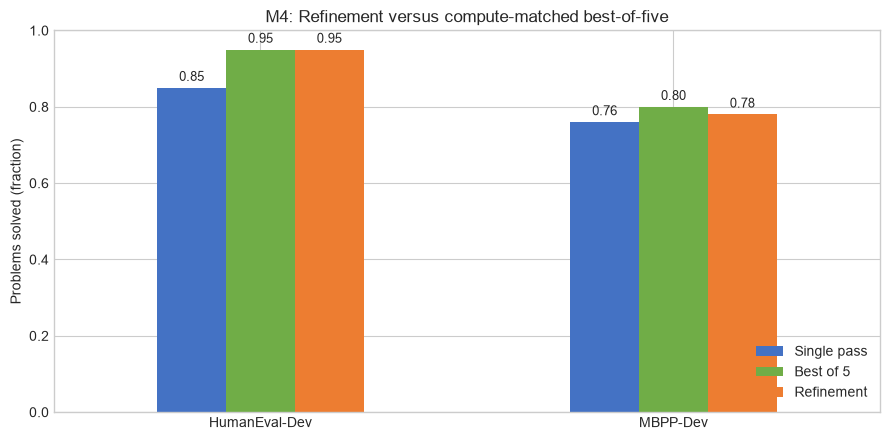

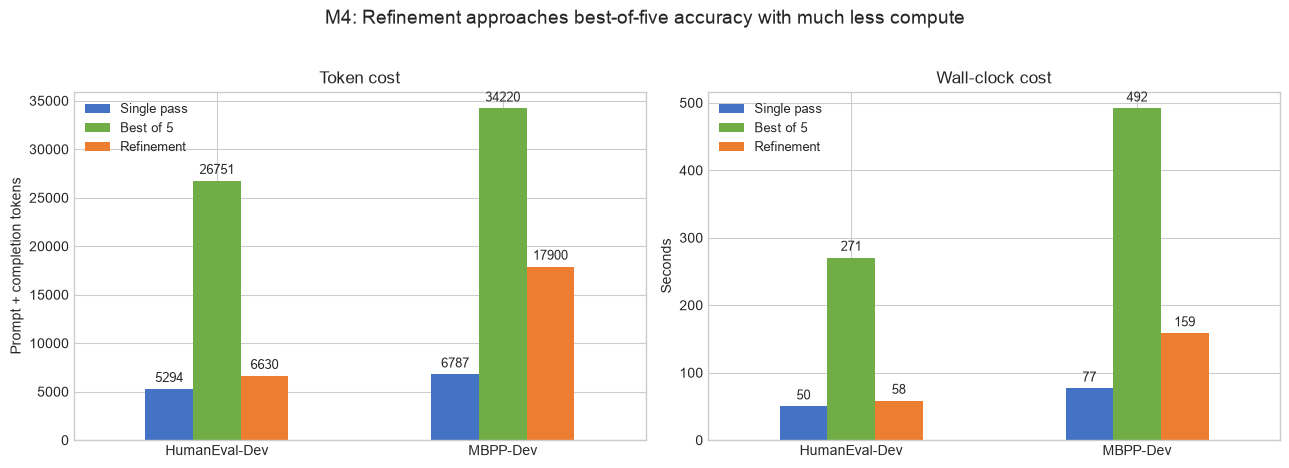

<div style='padding:12px;border-left:5px solid #4472C4;background:#edf4ff'><b>MBPP entry-point bug:</b> the original prompt omitted the required function signature. We caught it because <b>45/47</b> failures were <code>NameError</code> failures—not logic errors. The prompt contract was corrected and every M4+ result shown here uses post-fix artifacts.</div>

In [4]:
m4_rows = []
config_runs = [("Single pass", "single"), ("Best of 5", "bo5"), ("Refinement", "refined")]
for benchmark in RUNS["single"]:
    for label, key in config_runs:
        row = summary_row(RUNS[key][benchmark])
        m4_rows.append({
            "Benchmark": benchmark,
            "Configuration": label,
            "Score": row["value"],
            "Tokens": row["prompt_tokens"] + row["completion_tokens"],
            "Wall-clock seconds": row["wall_clock_seconds"],
        })
m4_long = pd.DataFrame(m4_rows)
m4 = m4_long.pivot(index="Benchmark", columns="Configuration", values="Score")[["Single pass", "Best of 5", "Refinement"]]
display(m4.style.format("{:.2f}").set_caption("M4: accuracy under the three required configurations"))
ax = m4.plot.bar(color=COLORS, figsize=(9, 4.5), ylim=(0, 1))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M4: Refinement versus compute-matched best-of-five")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", loc="lower right")
label_bars(ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, measure, title, ylabel in [
    (axes[0], "Tokens", "Token cost", "Prompt + completion tokens"),
    (axes[1], "Wall-clock seconds", "Wall-clock cost", "Seconds"),
]:
    cost = m4_long.pivot(index="Benchmark", columns="Configuration", values=measure)[["Single pass", "Best of 5", "Refinement"]]
    cost.plot.bar(ax=ax, color=COLORS)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="", fontsize=9)
    label_bars(ax, digits=0)
fig.suptitle("M4: Refinement approaches best-of-five accuracy with much less compute", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

invalid_records = [json.loads(path.read_text()) for path in (INVALID_MBPP / "problems").glob("*.json")]
invalid_failures = [record for record in invalid_records if not record["passed"]]
name_error_failures = sum(
    any(test["exception_type"] == "NameError" for test in record["iterations"][0]["execution"]["tests"])
    for record in invalid_failures
)
display(Markdown(
    f"<div style='padding:12px;border-left:5px solid #4472C4;background:#edf4ff'>"
    f"<b>MBPP entry-point bug:</b> the original prompt omitted the required function signature. We caught it because "
    f"<b>{name_error_failures}/{len(invalid_failures)}</b> failures were <code>NameError</code> failures—not logic errors. "
    f"The prompt contract was corrected and every M4+ result shown here uses post-fix artifacts.</div>"
))

## M5 — Feedback strategy comparison

Strategy,Template,Trace,Hybrid
Benchmark,,,
HumanEval-Dev,0.95,0.90,0.90
MBPP-Dev,0.78,0.84,0.84


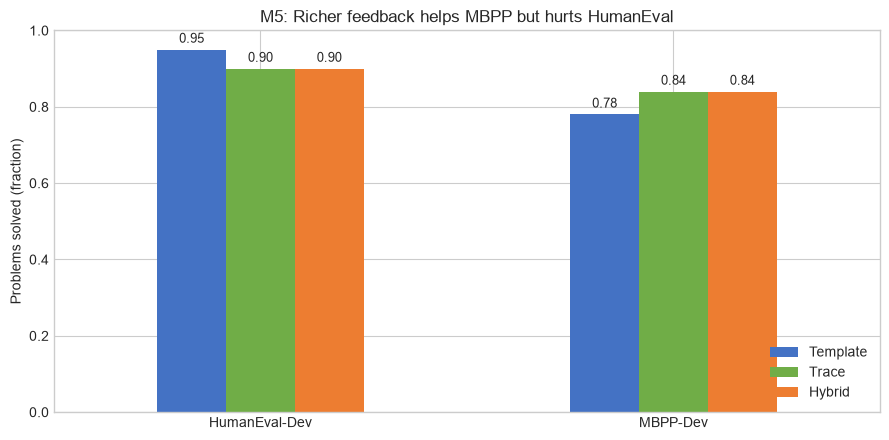

<div style='padding:12px;border-left:5px solid #C00000;background:#fff0f0'><b>Genuine trade-off:</b> trace/hybrid improved MBPP from <b>0.78</b> to <b>0.84</b>, but HumanEval moved from <b>0.95</b> to <b>0.90</b>. This negative result is part of the finding, not something to smooth over.</div>

In [5]:
m5_rows = []
for benchmark in RUNS["template"]:
    for label, key in [("Template", "template"), ("Trace", "trace"), ("Hybrid", "hybrid")]:
        m5_rows.append({"Benchmark": benchmark, "Strategy": label, "Score": summary_row(RUNS[key][benchmark])["value"]})
m5 = pd.DataFrame(m5_rows).pivot(index="Benchmark", columns="Strategy", values="Score")[["Template", "Trace", "Hybrid"]]
display(m5.style.format("{:.2f}").set_caption("M5: pass@1_refined by feedback strategy"))
ax = m5.plot.bar(color=COLORS, figsize=(9, 4.5), ylim=(0, 1))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M5: Richer feedback helps MBPP but hurts HumanEval")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", loc="lower right")
label_bars(ax)
plt.tight_layout()
plt.show()

he_template, he_trace = m5.loc["HumanEval-Dev", ["Template", "Trace"]]
mb_template, mb_trace = m5.loc["MBPP-Dev", ["Template", "Trace"]]
display(Markdown(
    f"<div style='padding:12px;border-left:5px solid #C00000;background:#fff0f0'>"
    f"<b>Genuine trade-off:</b> trace/hybrid improved MBPP from <b>{mb_template:.2f}</b> to <b>{mb_trace:.2f}</b>, "
    f"but HumanEval moved from <b>{he_template:.2f}</b> to <b>{he_trace:.2f}</b>. This negative result is part of the finding, not something to smooth over.</div>"
))

## Six case studies — where feedback helps and where it fails

In [6]:
case_ids = ["HumanEval/46", "HumanEval/75", "HumanEval/83", "MBPP/446", "MBPP/597", "MBPP/734"]

def outcome_text(record):
    iterations = len(record["iterations"])
    if record["passed"]:
        return f"Solved (iteration {iterations})"
    return f"Unsolved ({record['convergence_reason']}, iteration {iterations})"

case_rows = []
for task_id in case_ids:
    benchmark = "HumanEval-Dev" if task_id.startswith("HumanEval") else "MBPP-Dev"
    records = {key: problem_record(RUNS[key][benchmark], task_id) for key in ("template", "trace", "hybrid")}
    category = records["template"]["iterations"][0]["classification"]["category"].replace("_", " ").title()
    case_rows.append({
        "Case": task_id,
        "Benchmark": benchmark,
        "Initial category": category,
        "Template": outcome_text(records["template"]),
        "Trace": outcome_text(records["trace"]),
        "Hybrid": outcome_text(records["hybrid"]),
    })
case_table = pd.DataFrame(case_rows).set_index("Case")
display(case_table.style.set_caption("Named cases across all M5 feedback strategies").set_properties(**{"text-align": "left"}))

he83 = case_table.loc["HumanEval/83"]
display(Markdown(
    f"<div style='padding:12px;border-left:5px solid #7030A0;background:#f5effa'>"
    f"<b>HumanEval/83 is the clearest warning:</b> template feedback produced <b>{he83['Template']}</b>, while trace produced <b>{he83['Trace']}</b>. More detailed feedback can steer a deterministic model into a worse refinement path.</div>"
))

,Benchmark,Initial category,Template,Trace,Hybrid
Case,,,,,
HumanEval/46,HumanEval-Dev,Logic,"Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)"
HumanEval/75,HumanEval-Dev,Edge Case,Solved (iteration 2),Solved (iteration 2),Solved (iteration 2)
HumanEval/83,HumanEval-Dev,Edge Case,Solved (iteration 2),"Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)"
MBPP/446,MBPP-Dev,Logic,Solved (iteration 2),Solved (iteration 2),Solved (iteration 2)
MBPP/597,MBPP-Dev,Runtime,"Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)"
MBPP/734,MBPP-Dev,Edge Case,"Unsolved (oscillation, iteration 3)",Solved (iteration 2),Solved (iteration 2)


<div style='padding:12px;border-left:5px solid #7030A0;background:#f5effa'><b>HumanEval/83 is the clearest warning:</b> template feedback produced <b>Solved (iteration 2)</b>, while trace produced <b>Unsolved (oscillation, iteration 2)</b>. More detailed feedback can steer a deterministic model into a worse refinement path.</div>

## Takeaways so far

Letting the model see and respond to its mistakes can solve problems that one attempt misses, often with much less work than generating several independent answers. However, more detailed feedback is not automatically better: it helped one benchmark while making another slightly worse, so the next stage must measure carefully which kinds of feedback are dependable.